In [ ]:
# Основные библиотеки
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Предобработка данных
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Метрики
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# Настройки отображения
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
import kagglehub

# Загрузка датасета
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Путь к файлам:", path)

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Путь к файлам: /kaggle/input/hotel-booking-demand


In [ ]:
import os

# Посмотрим содержимое папки
print(os.listdir(path))

['hotel_bookings.csv']


In [ ]:
# Обычно файл называется hotel_bookings.csv
data = pd.read_csv(f"{path}/hotel_bookings.csv")

# Первые строки
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
print("Размер датасета:", data.shape)

Размер датасета: (119390, 32)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
data.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [ ]:
missing = data.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
company,112593
agent,16340
country,488
children,4


In [ ]:
# Заполняем пропуски

data['children'] = data['children'].fillna(data['children'].median())
data['country'] = data['country'].fillna(data['country'].mode()[0])
data['agent'] = data['agent'].fillna(0)
data['company'] = data['company'].fillna(0)

print("Пропуски после обработки:")
print(data.isnull().sum().sum())

Пропуски после обработки:
0


In [ ]:
print("Количество дубликатов:", data.duplicated().sum())

Количество дубликатов: 32013


In [ ]:
# Удаляем дубликаты
data = data.drop_duplicates()

print("Размер после удаления дубликатов:", data.shape)

Размер после удаления дубликатов: (87377, 32)


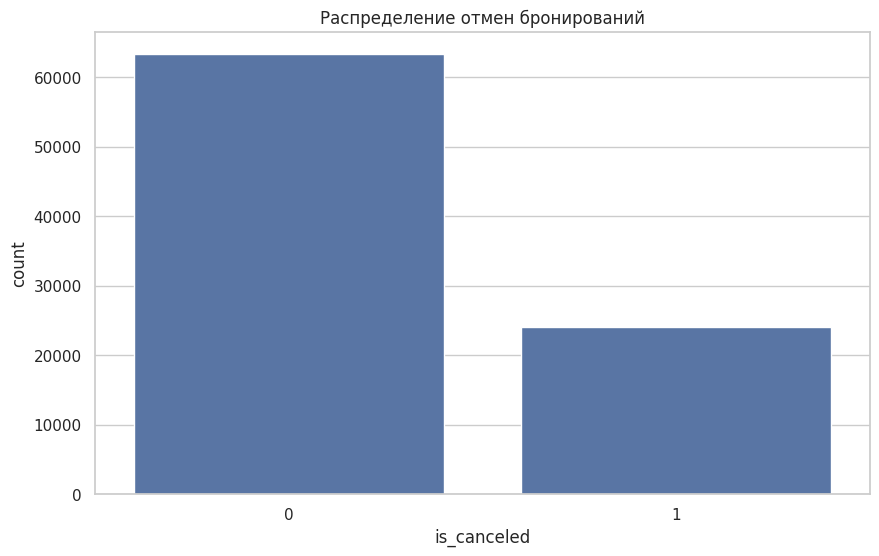

In [ ]:
sns.countplot(x='is_canceled', data=data)
plt.title("Распределение отмен бронирований")
plt.show()

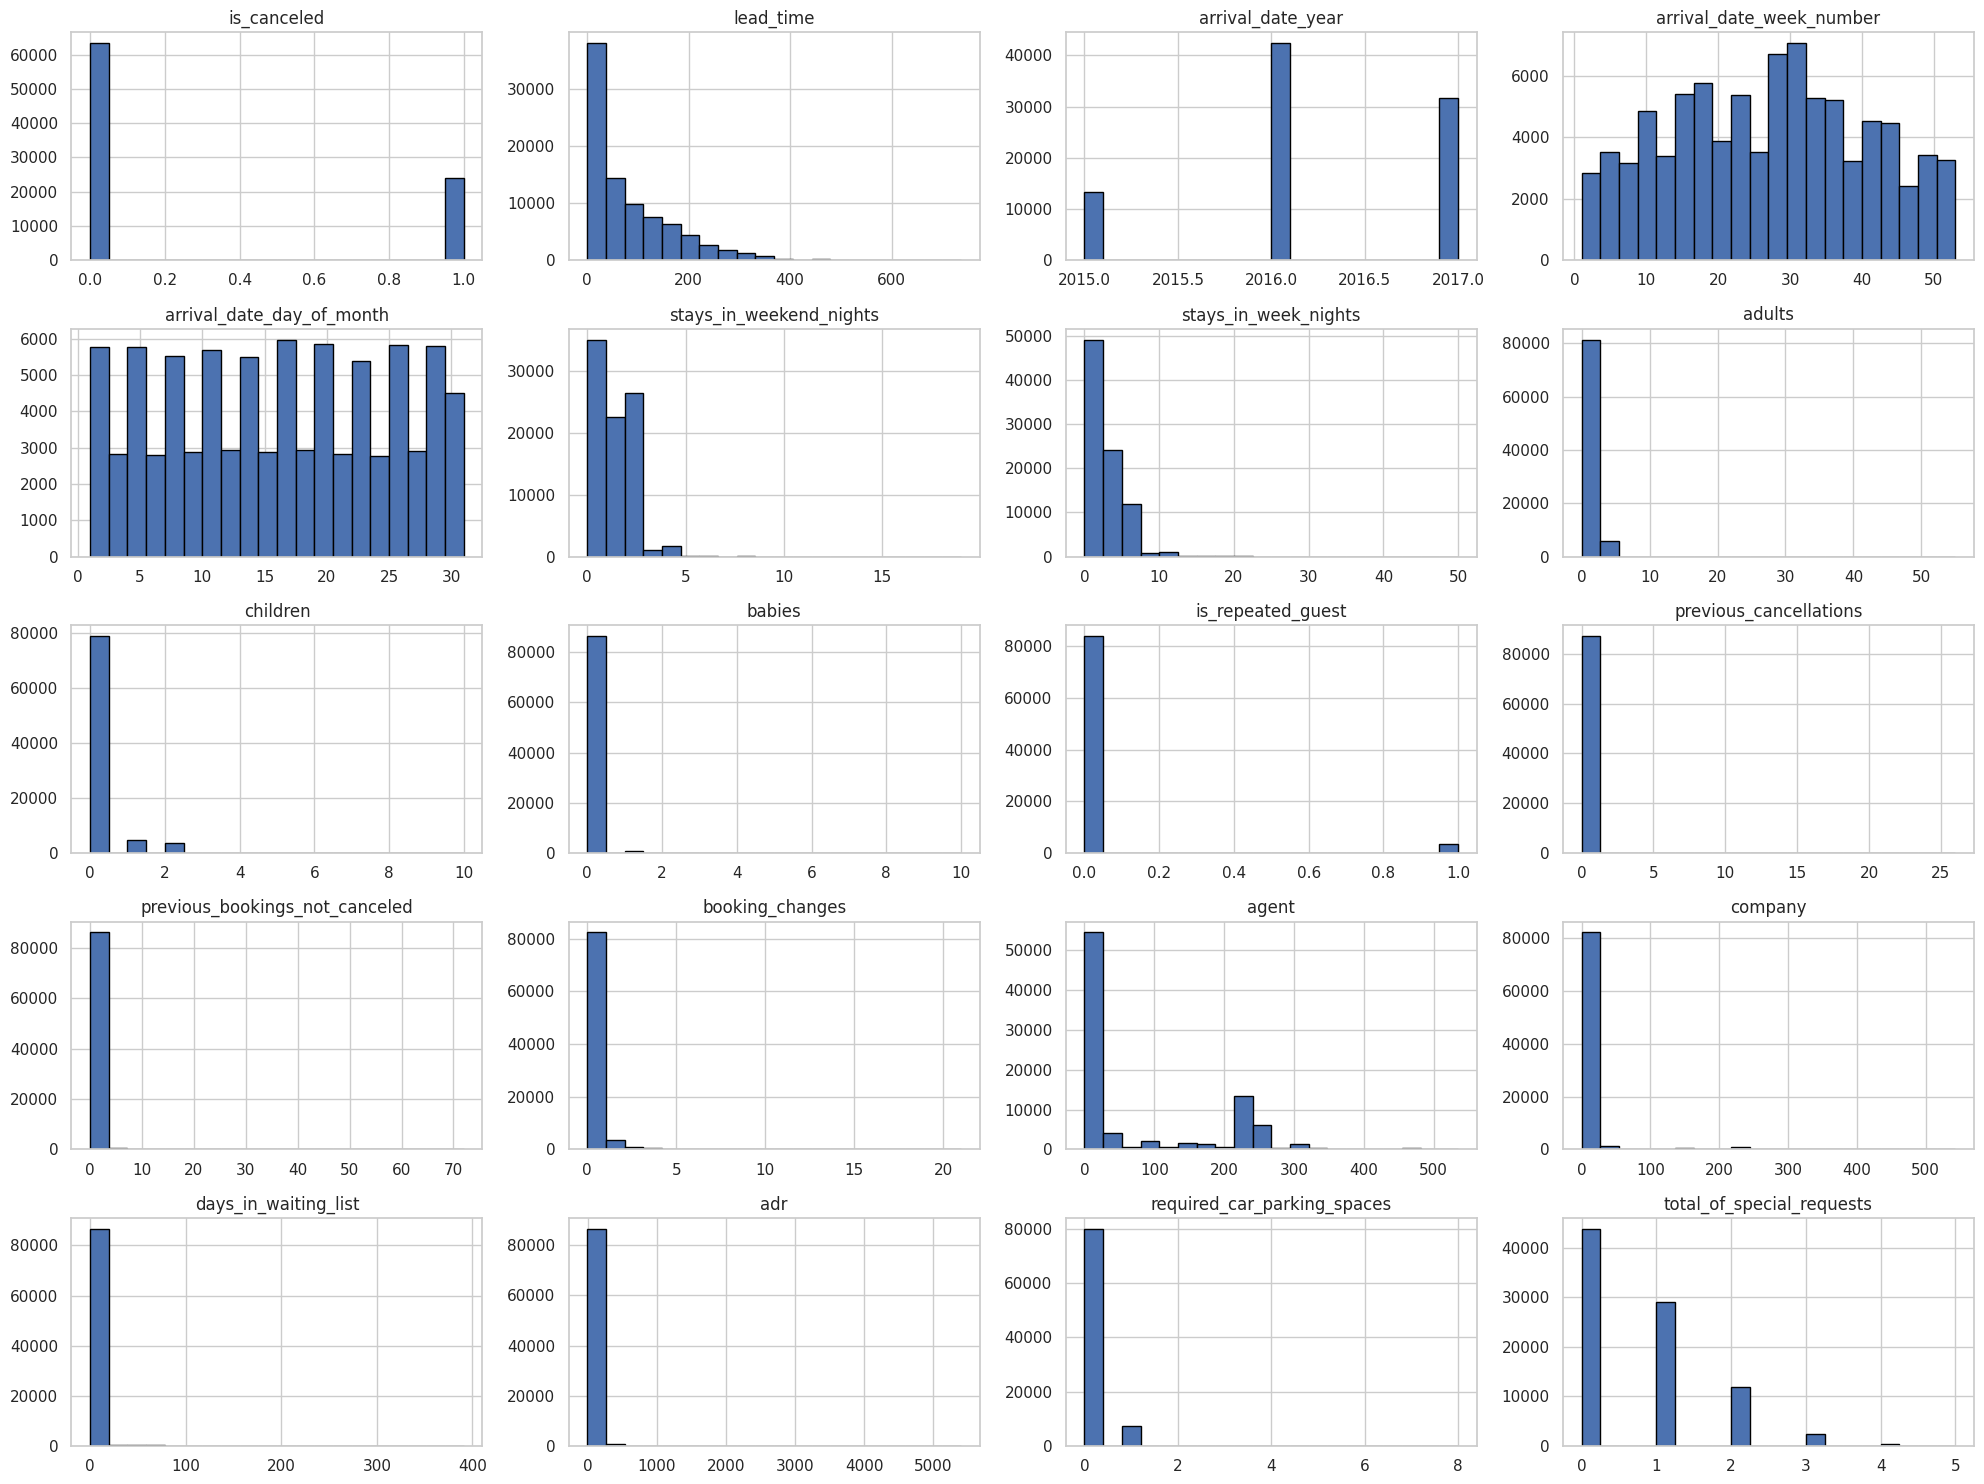

In [ ]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

data[numeric_cols].hist(
    bins=20,
    figsize=(20, 15),
    edgecolor='black'
)

plt.tight_layout()
plt.show()

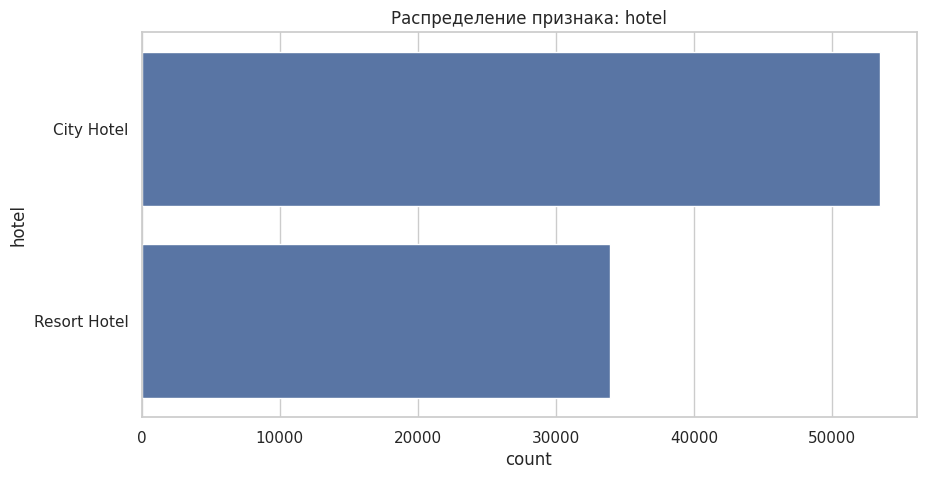

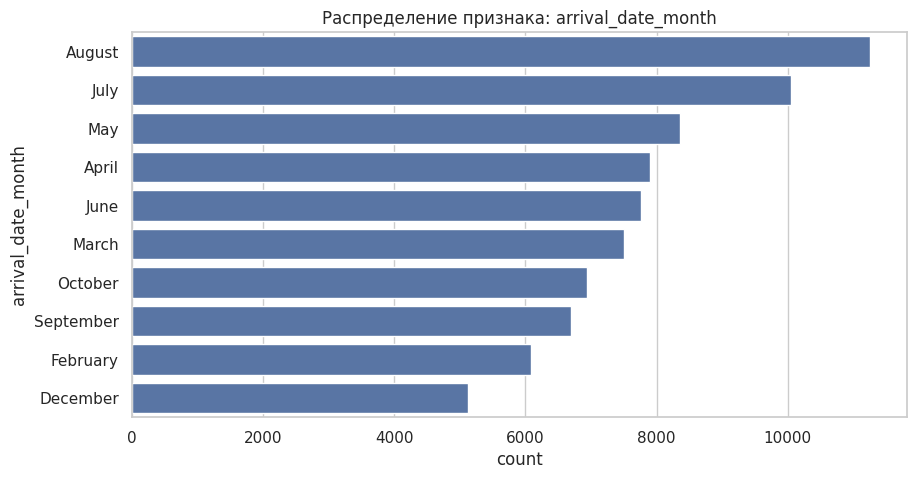

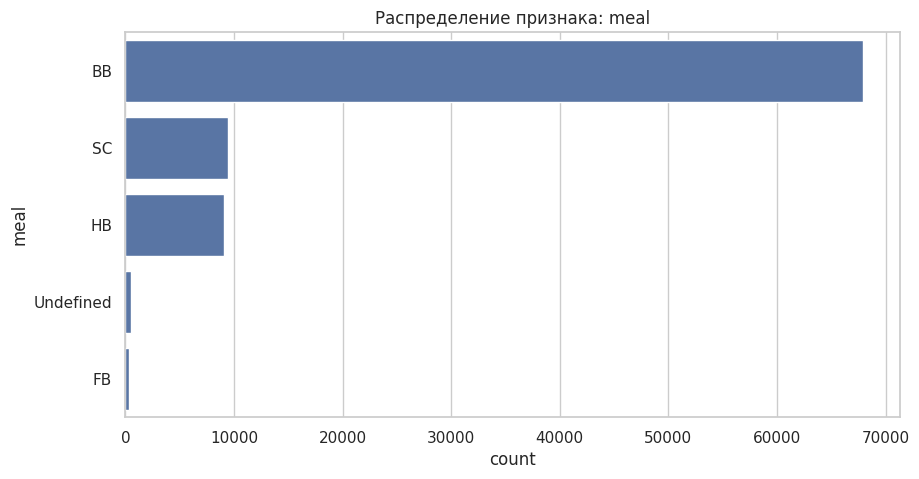

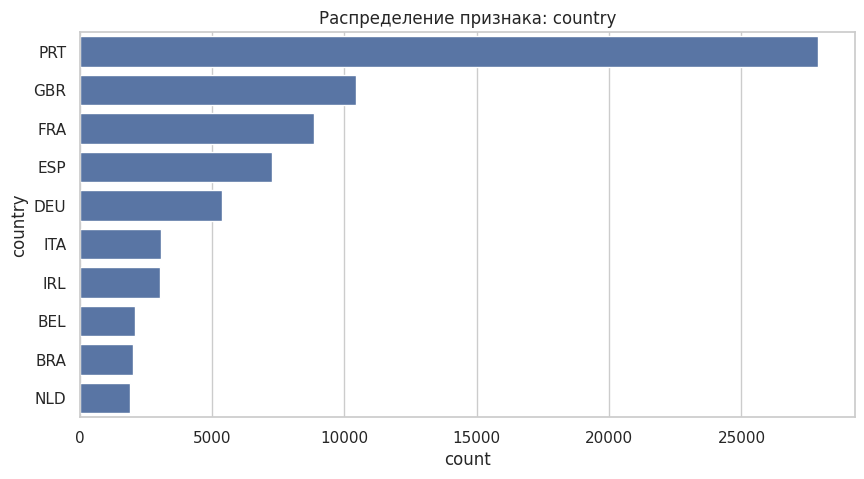

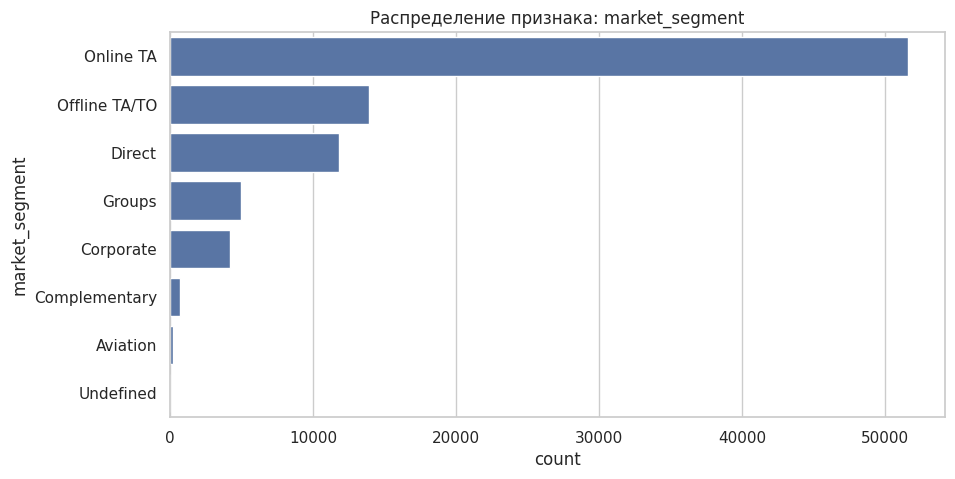

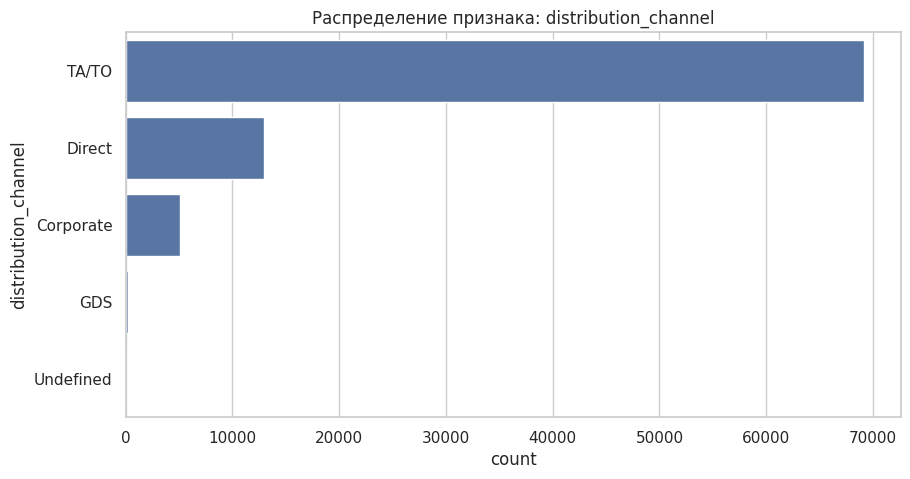

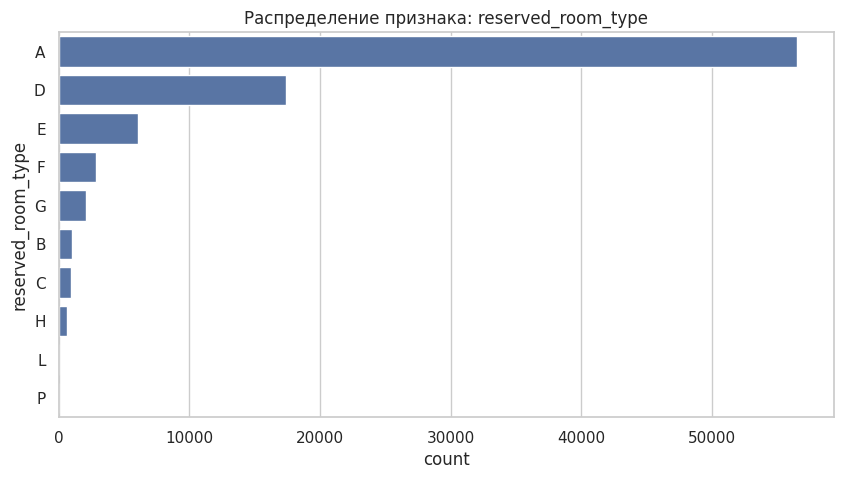

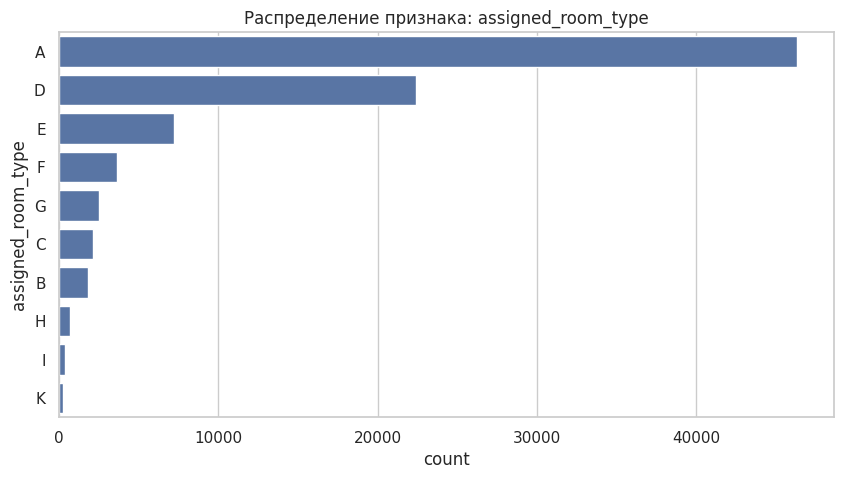

In [ ]:
categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols[:8]:
    plt.figure(figsize=(10,5))
    sns.countplot(
        y=col,
        data=data,
        order=data[col].value_counts().index[:10]
    )
    plt.title(f"Распределение признака: {col}")
    plt.show()

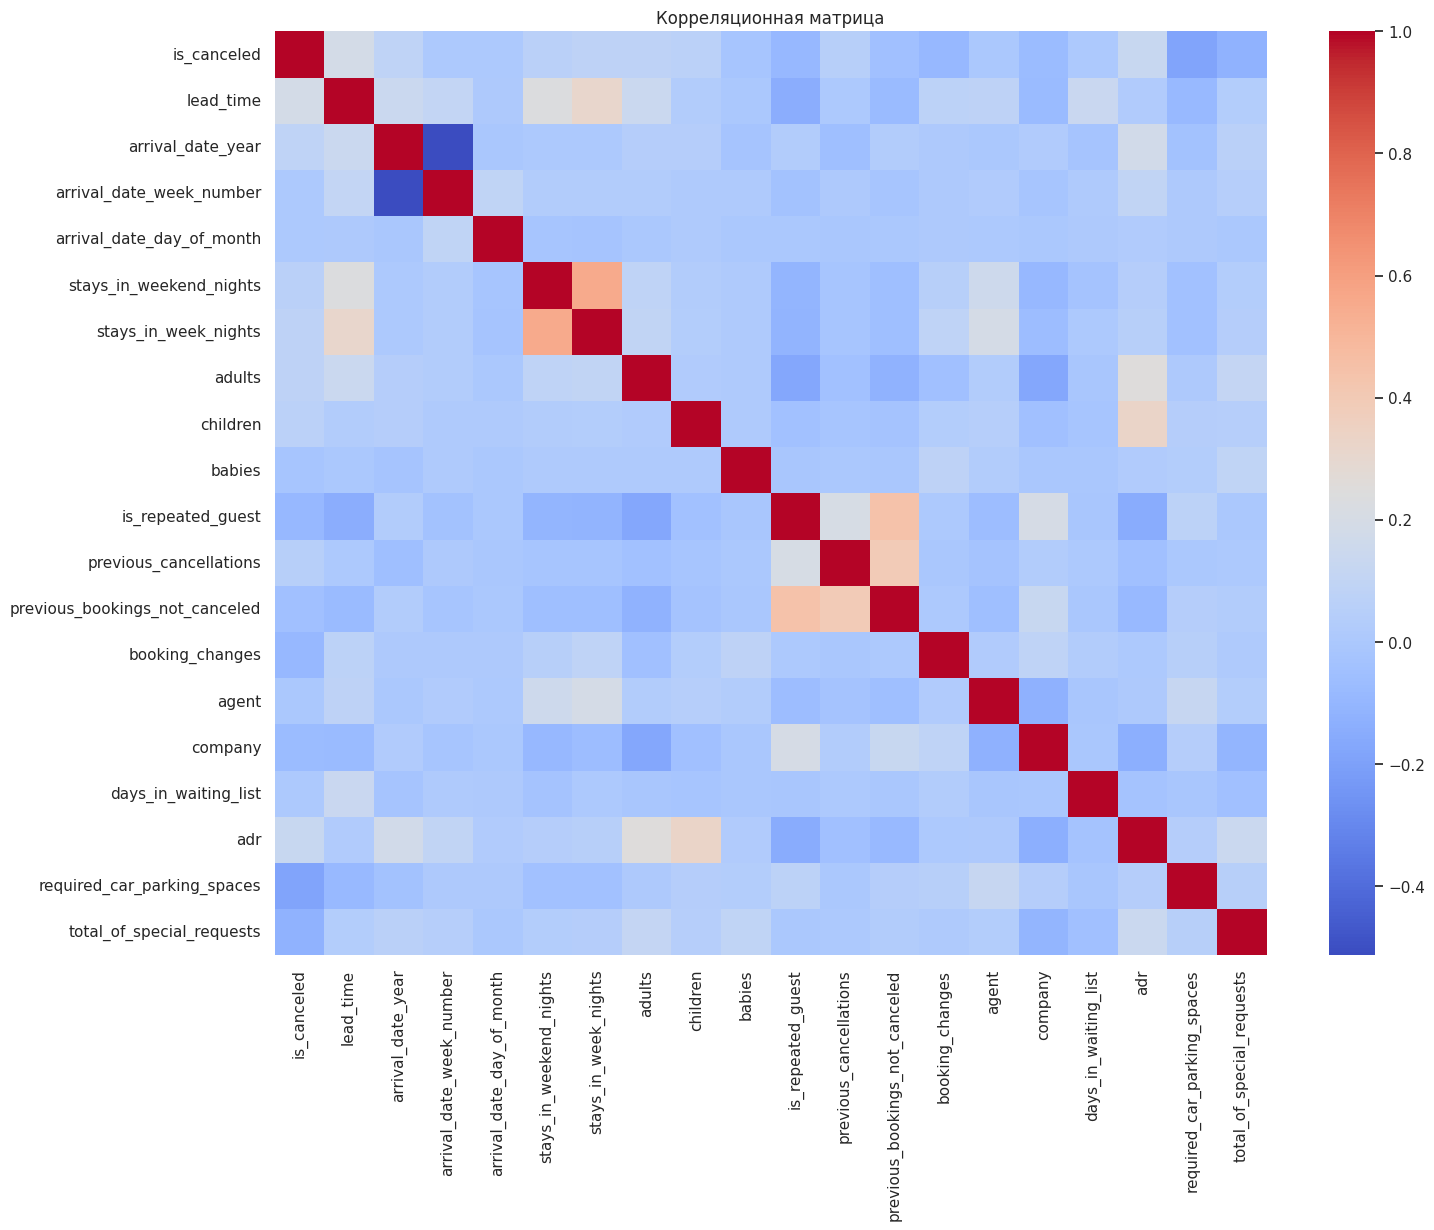

In [ ]:
plt.figure(figsize=(16, 12))

corr = data[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm'
)

plt.title("Корреляционная матрица")
plt.show()

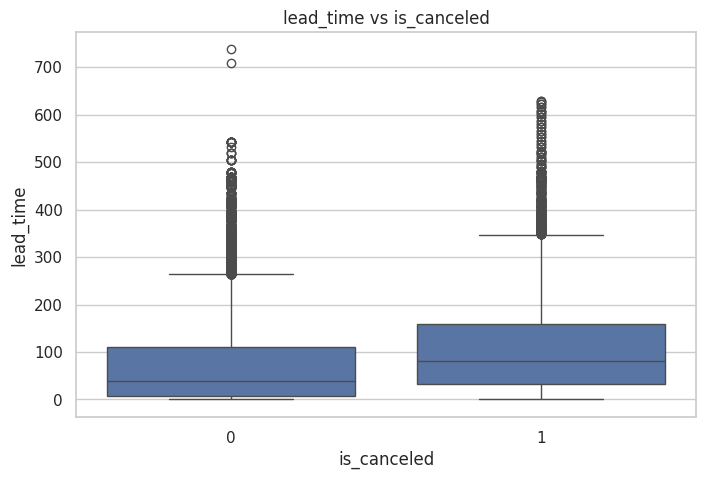

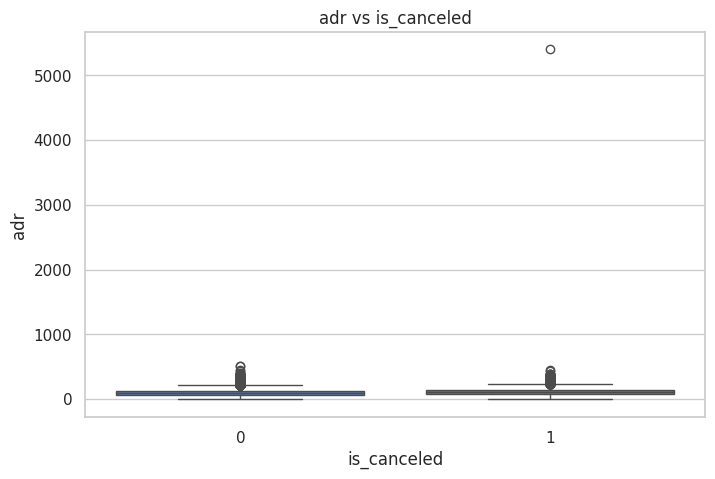

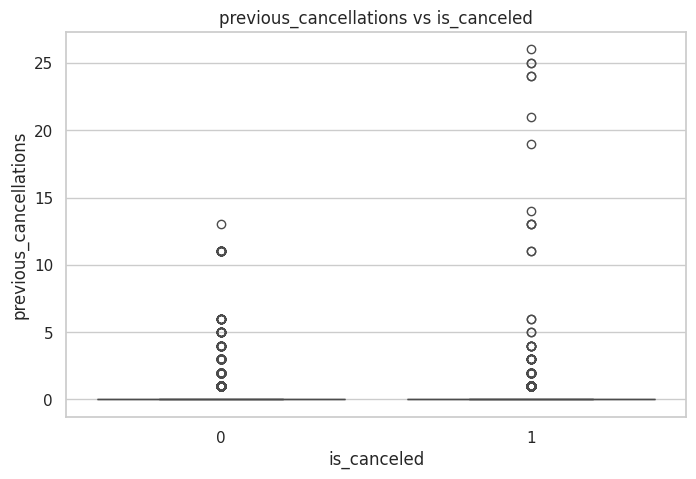

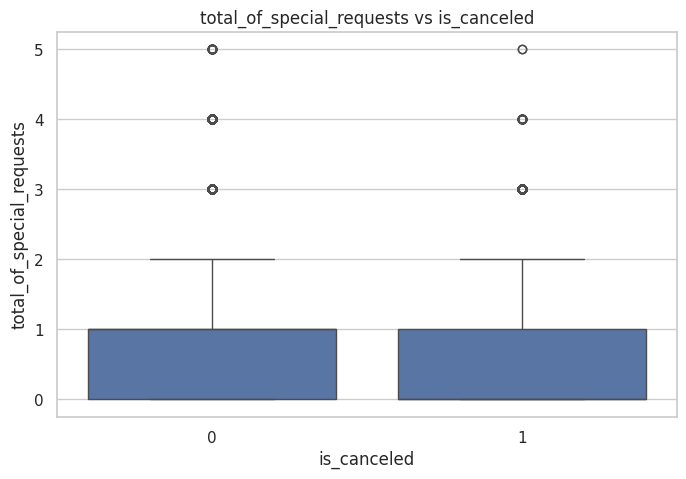

In [ ]:
important_features = [
    'lead_time',
    'adr',
    'previous_cancellations',
    'total_of_special_requests'
]

for feature in important_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        x='is_canceled',
        y=feature,
        data=data
    )
    plt.title(f"{feature} vs is_canceled")
    plt.show()

In [ ]:
X = data.drop("is_canceled", axis=1)
y = data["is_canceled"]

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(69901, 31) (17476, 31)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLPClassifier": MLPClassifier(max_iter=500, random_state=42)
}


Обучаем модель: Logistic Regression
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12671
           1       1.00      1.00      1.00      4805

    accuracy                           1.00     17476
   macro avg       1.00      1.00      1.00     17476
weighted avg       1.00      1.00      1.00     17476



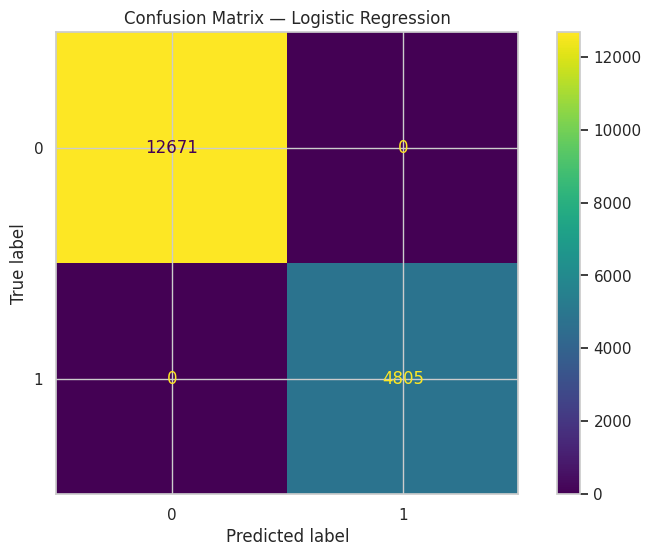


Обучаем модель: Random Forest
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12671
           1       1.00      1.00      1.00      4805

    accuracy                           1.00     17476
   macro avg       1.00      1.00      1.00     17476
weighted avg       1.00      1.00      1.00     17476



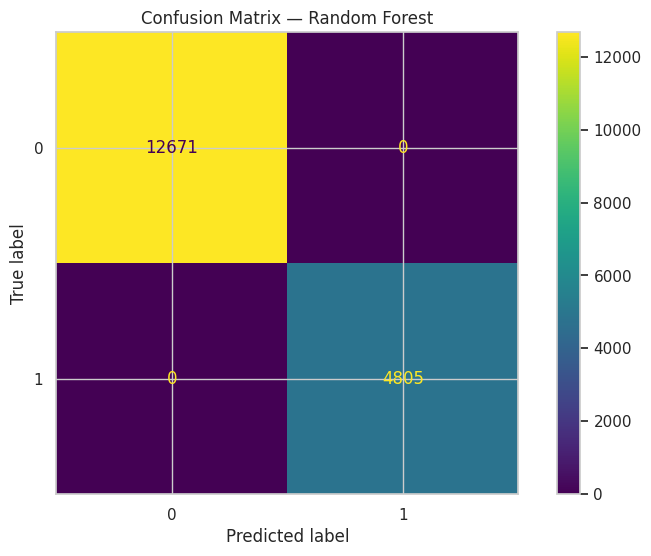


Обучаем модель: Gradient Boosting
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12671
           1       1.00      1.00      1.00      4805

    accuracy                           1.00     17476
   macro avg       1.00      1.00      1.00     17476
weighted avg       1.00      1.00      1.00     17476



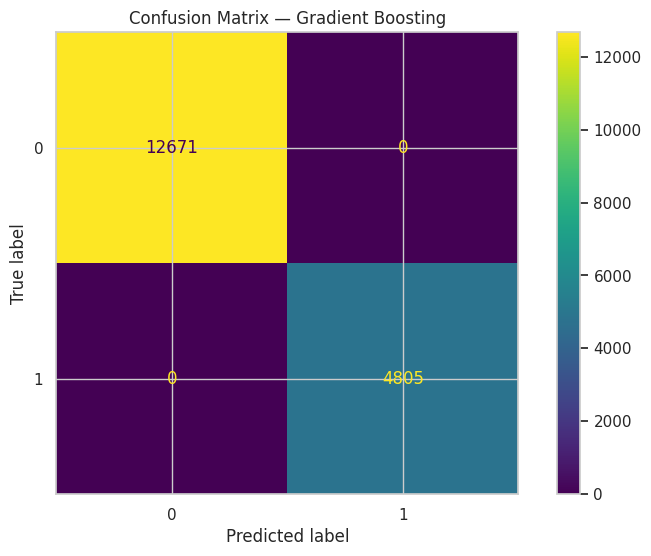


Обучаем модель: MLPClassifier
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12671
           1       1.00      1.00      1.00      4805

    accuracy                           1.00     17476
   macro avg       1.00      1.00      1.00     17476
weighted avg       1.00      1.00      1.00     17476



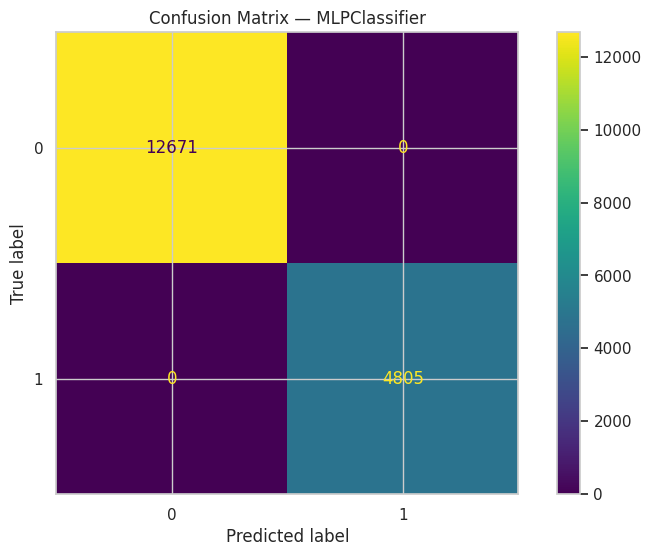

In [ ]:
results = []

for name, model in models.items():
    print(f"\nОбучаем модель: {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

    results.append([name, accuracy])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Модель", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Модель,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0
2,Gradient Boosting,1.0
3,MLPClassifier,1.0


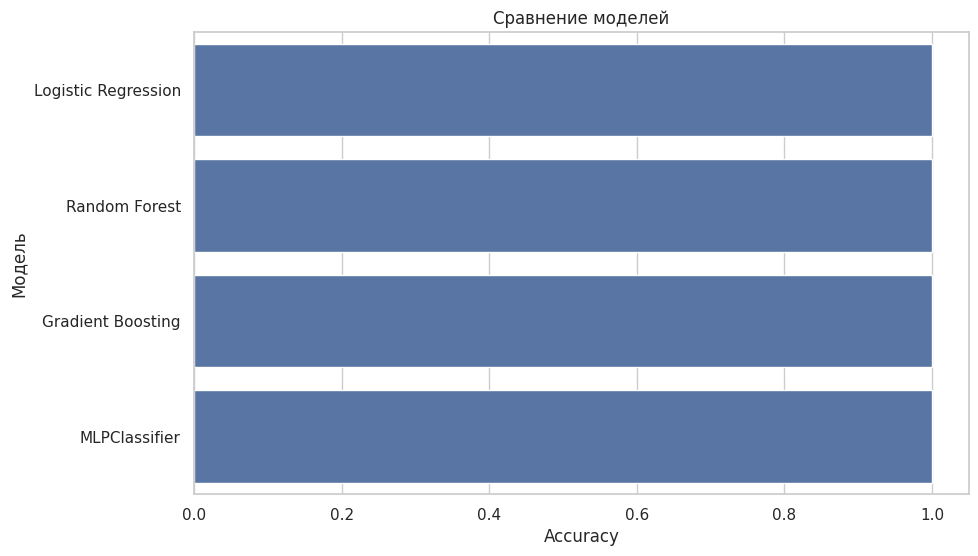

In [ ]:
sns.barplot(
    x="Accuracy",
    y="Модель",
    data=results_df
)

plt.title("Сравнение моделей")
plt.show()

In [ ]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_cha...
       'total_of_special_requests'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
rf_model = best_model.named_steps["model"]

importances = rf_model.feature_importances_

print("Feature importance рассчитана")

Feature importance рассчитана


In [ ]:
print("""
Идея развертывания модели:

Можно создать Streamlit-приложение,
в котором менеджер отеля сможет вводить
характеристики бронирования и получать
прогноз вероятности отмены брони.
""")


Идея развертывания модели:

Можно создать Streamlit-приложение,
в котором менеджер отеля сможет вводить
характеристики бронирования и получать
прогноз вероятности отмены брони.

